# Weather- and Holiday-Aware Retail Demand Forecasting
## Data Wrangling & Exploratory Data Analysis

**Capstone Three — Data Science Career Track**

**Problem statement:** Retailers over/under-stock because standard forecasts rely only on
historical sales and ignore external demand drivers like weather and holidays. This notebook
wrangles and explores daily/weekly **category-level sales**, joined with **weather** and
**holiday calendar** data, to answer:

1. Can external factors (weather, holidays) improve on a sales-history-only forecast?
2. Which product categories are most sensitive to weather and holidays?

---
### Data sources 
- **Sales + holidays:** [Corporación Favorita Grocery Sales Forecasting (Kaggle)](https://www.kaggle.com/c/favorita-grocery-sales-forecasting)
  — includes `train.csv` (date, store, item/category, sales), `holidays_events.csv`, `stores.csv`.
- **Weather:** [Open-Meteo Historical API](https://open-meteo.com/) or [NOAA CDO](https://www.ncdc.noaa.gov/cdo-web/),
  joined on date.

> This notebook runs on a **synthetic dataset that mimics the real schema and dynamics**
> (seasonality, holiday spikes, weather sensitivity, stockouts) so every cell is runnable
> end-to-end right now. Replace `load_sales()`, `load_weather()`, and `load_holidays()`
> in Section 1 with real file/API loaders and every downstream cell works unchanged.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 50)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 1. Data Wrangling

### 1.1 Load raw sources
Three independent sources on three different natural grains:
- **Sales**: daily, per store/category
- **Weather**: daily, per region
- **Holidays**: calendar events, not tied to a store

In [2]:
def load_sales(start="2019-01-01", end="2023-12-31", n_categories=6, n_stores=3, seed=RANDOM_SEED):
    """Simulates a Favorita-like daily sales table: date, store, category, sales, on_promo."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start, end, freq="D")
    categories = ["Beverages", "Produce", "Bakery", "Frozen Foods", "Cold Weather Apparel", "Cleaning Supplies"][:n_categories]
    stores = [f"Store_{i+1}" for i in range(n_stores)]

    base_level = {"Beverages": 400, "Produce": 350, "Bakery": 200, "Frozen Foods": 180,
                  "Cold Weather Apparel": 60, "Cleaning Supplies": 120}
    weekly_amp = {"Beverages": 80, "Produce": 40, "Bakery": 60, "Frozen Foods": 20,
                  "Cold Weather Apparel": 10, "Cleaning Supplies": 15}

    rows = []
    for store in stores:
        store_factor = rng.uniform(0.85, 1.15)
        for cat in categories:
            level = base_level[cat] * store_factor
            noise = rng.normal(0, level * 0.08, size=len(dates))
            dow = dates.dayofweek.values
            weekly = weekly_amp[cat] * np.where(dow >= 5, 1, -0.3)  # weekend bump
            annual = level * 0.15 * np.sin(2 * np.pi * (dates.dayofyear.values / 365.25))
            trend = np.linspace(0, level * 0.1, len(dates))  # mild growth
            sales = level + weekly + annual + trend + noise
            sales = np.clip(sales, 0, None)
            rows.append(pd.DataFrame({
                "date": dates, "store": store, "category": cat, "sales": sales.round(0)
            }))
    df = pd.concat(rows, ignore_index=True)

    # inject occasional stockouts (sales forced to 0, unrelated to real demand)
    stockout_mask = rng.random(len(df)) < 0.01
    df.loc[stockout_mask, "sales"] = 0
    df["stockout_flag"] = stockout_mask

    # promo flag, ~8% of rows
    df["on_promo"] = rng.random(len(df)) < 0.08
    df.loc[df["on_promo"], "sales"] *= rng.uniform(1.2, 1.6, size=df["on_promo"].sum())

    return df


def load_weather(start="2019-01-01", end="2023-12-31", seed=RANDOM_SEED):
    """Simulates daily weather: temp (F), precipitation (in), snow flag."""
    rng = np.random.default_rng(seed + 1)
    dates = pd.date_range(start, end, freq="D")
    doy = dates.dayofyear.values
    seasonal_temp = 55 + 25 * np.sin(2 * np.pi * (doy - 105) / 365.25)  # peak ~mid-July
    temp = seasonal_temp + rng.normal(0, 8, size=len(dates))
    precip = np.clip(rng.gamma(shape=0.6, scale=0.25, size=len(dates)), 0, None)
    precip[rng.random(len(dates)) > 0.35] = 0  # most days are dry
    snow_flag = (temp < 34) & (precip > 0.05) & (rng.random(len(dates)) < 0.6)
    extreme_cold = temp < 20
    extreme_heat = temp > 92
    return pd.DataFrame({
        "date": dates, "temp_f": temp.round(1), "precip_in": precip.round(2),
        "snow_flag": snow_flag, "extreme_cold": extreme_cold, "extreme_heat": extreme_heat
    })


def load_holidays(start="2019-01-01", end="2023-12-31"):
    """Simulates a holiday calendar with a type, similar to Favorita's holidays_events.csv."""
    years = range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1)
    fixed = [("01-01", "New Year's Day", "national"), ("07-04", "Independence Day", "national"),
             ("12-25", "Christmas Day", "national"), ("11-11", "Veterans Day", "national"),
             ("02-14", "Valentine's Day", "promotional"), ("10-31", "Halloween", "promotional")]
    rows = []
    for y in years:
        for md_, name, htype in fixed:
            rows.append({"date": pd.Timestamp(f"{y}-{md_}"), "holiday_name": name, "holiday_type": htype})
        # floating: Thanksgiving = 4th Thursday of November
        nov = pd.date_range(f"{y}-11-01", f"{y}-11-30", freq="D")
        thursdays = nov[nov.dayofweek == 3]
        rows.append({"date": thursdays[3], "holiday_name": "Thanksgiving", "holiday_type": "national"})
    return pd.DataFrame(rows).drop_duplicates(subset="date").sort_values("date").reset_index(drop=True)


sales_df = load_sales()
weather_df = load_weather()
holidays_df = load_holidays()

print(sales_df.shape, weather_df.shape, holidays_df.shape)
sales_df.head()


(32868, 6) (1826, 6) (35, 3)


,date,store,category,sales,stockout_flag,on_promo
0,2019-01-01,Store_1,Beverages,374.000000,False,False
1,2019-01-02,Store_1,Beverages,437.000000,False,False
2,2019-01-03,Store_1,Beverages,445.000000,False,False
3,2019-01-04,Store_1,Beverages,346.000000,False,False
4,2019-01-05,Store_1,Beverages,670.814325,False,True


In [3]:
weather_df.head()

,date,temp_f,precip_in,snow_flag,extreme_cold,extreme_heat
0,2019-01-01,32.5,0.00,False,False,False
1,2019-01-02,35.9,0.18,False,False,False
2,2019-01-03,25.7,0.00,False,False,False
3,2019-01-04,23.1,0.00,False,False,False
4,2019-01-05,14.3,0.00,False,True,False


In [4]:
holidays_df.head()

,date,holiday_name,holiday_type
0,2019-01-01,New Year's Day,national
1,2019-02-14,Valentine's Day,promotional
2,2019-07-04,Independence Day,national
3,2019-10-31,Halloween,promotional
4,2019-11-11,Veterans Day,national


### 1.2 Align grains and merge

Sales is the base table (date x store x category). Weather is joined on `date` only
(single-region assumption here — with real multi-region data, join on date + region/store).
Holidays are joined on `date` and expanded into a boolean flag + proximity feature.


In [3]:
df = sales_df.merge(weather_df, on="date", how="left")
df = df.merge(holidays_df[["date", "holiday_name", "holiday_type"]], on="date", how="left")
df["is_holiday"] = df["holiday_name"].notna()

print("Missing weather after merge:", df["temp_f"].isna().sum())
print("Missing holiday flag after merge:", df["is_holiday"].isna().sum())
df.head()


Missing weather after merge: 0
Missing holiday flag after merge: 0


,date,store,category,sales,stockout_flag,on_promo,temp_f,precip_in,snow_flag,extreme_cold,extreme_heat,holiday_name,holiday_type,is_holiday
0,2019-01-01,Store_1,Beverages,374.000000,False,False,32.5,0.00,False,False,False,New Year's Day,national,True
1,2019-01-02,Store_1,Beverages,437.000000,False,False,35.9,0.18,False,False,False,NaN,NaN,False
2,2019-01-03,Store_1,Beverages,445.000000,False,False,25.7,0.00,False,False,False,NaN,NaN,False
3,2019-01-04,Store_1,Beverages,346.000000,False,False,23.1,0.00,False,False,False,NaN,NaN,False
4,2019-01-05,Store_1,Beverages,670.814325,False,True,14.3,0.00,False,True,False,NaN,NaN,False


### 1.3 Handle stockouts and missing data

A day with `sales == 0` is ambiguous: it could mean *no demand* or *no inventory*.
Conflating the two corrupts the response variable, so we keep `stockout_flag` as a
feature/filter rather than silently trusting raw sales as ground-truth demand.


In [4]:
print("Stockout rate:", df["stockout_flag"].mean().round(4))

# demand-only view for modeling response distribution (excludes stockout days)
df_demand = df[~df["stockout_flag"]].copy()

# forward/interpolate any weather gaps (none expected in synthetic data, but this is the
# real-world pattern for gappy station records)
df["temp_f"] = df["temp_f"].interpolate(limit_direction="both")
df["precip_in"] = df["precip_in"].fillna(0)


Stockout rate: 0.01


### 1.4 Feature engineering: time, lag, rolling, holiday-proximity

Standard demand-forecasting feature set: calendar features, lagged sales, rolling
statistics, and "distance to nearest holiday" (captures pre-holiday demand ramp-up).


In [5]:
df = df.sort_values(["store", "category", "date"]).reset_index(drop=True)

# calendar features
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = df["dow"] >= 5
df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# lag / rolling features, computed per store-category series
grp = df.groupby(["store", "category"])["sales"]
df["sales_lag_1"] = grp.shift(1)
df["sales_lag_7"] = grp.shift(7)
df["sales_roll_7"] = grp.transform(lambda s: s.shift(1).rolling(7).mean())
df["sales_roll_28"] = grp.transform(lambda s: s.shift(1).rolling(28).mean())

# days to nearest holiday (vectorized via merge_asof per direction)
hol_dates = pd.Series(sorted(holidays_df["date"].unique()))

def days_to_nearest_holiday(dates):
    dates = pd.to_datetime(dates)
    idx = np.searchsorted(hol_dates.values, dates.values)
    idx = np.clip(idx, 1, len(hol_dates) - 1)
    prev_gap = (dates.values - hol_dates.values[idx - 1]).astype("timedelta64[D]").astype(int)
    next_gap = (hol_dates.values[idx] - dates.values).astype("timedelta64[D]").astype(int)
    return np.minimum(prev_gap, next_gap)

df["days_to_holiday"] = days_to_nearest_holiday(df["date"])

df[["date", "store", "category", "sales", "sales_lag_7", "sales_roll_7", "days_to_holiday"]].tail()


,date,store,category,sales,sales_lag_7,sales_roll_7,days_to_holiday
32863,2023-12-27,Store_3,Produce,419.000000,344.000000,383.235042,-2
32864,2023-12-28,Store_3,Produce,406.000000,335.000000,393.949327,-3
32865,2023-12-29,Store_3,Produce,340.000000,450.645291,404.092184,-4
32866,2023-12-30,Store_3,Produce,458.000000,411.000000,388.285714,-5
32867,2023-12-31,Store_3,Produce,519.509558,443.000000,395.000000,-6


### 1.5 Time-respecting train/test split (for later modeling)

time series data is not shuffled — the holdout is the most recent period.


In [6]:
cutoff = df["date"].max() - pd.Timedelta(days=90)
train = df[df["date"] <= cutoff].copy()
test = df[df["date"] > cutoff].copy()
print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train)} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test)} rows)")


Train: 2019-01-01 to 2023-10-02  (31248 rows)
Test:  2023-10-03 to 2023-12-31  (1620 rows)


---
## 2. Exploratory Data Analysis

Following the capstone EDA checklist: response balance, feature distributions,
feature/response correlation, collinearity, outliers, and seasonal/linear trends —
each evaluated in the context of *which categories are weather- and holiday-sensitive*.


### 2.1 Is the response variable "unbalanced"? (zero-inflation / skew)

For a continuous demand target, "unbalanced" translates to: how zero-inflated and
right-skewed is sales? This affects model choice (e.g. Tweedie/zero-inflated models
vs. plain regression).


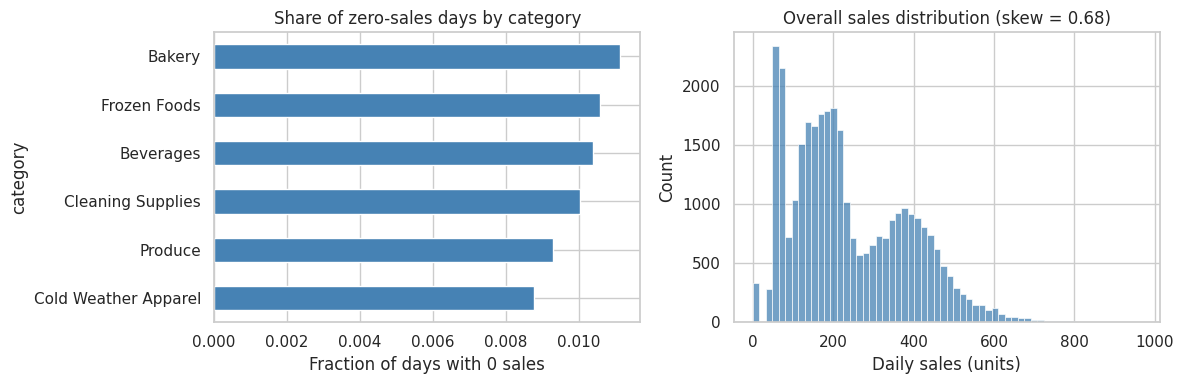

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

zero_share = (df.groupby("category")["sales"].apply(lambda s: (s == 0).mean()))
zero_share.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Share of zero-sales days by category")
axes[0].set_xlabel("Fraction of days with 0 sales")

sns.histplot(df["sales"], bins=60, ax=axes[1], color="steelblue")
axes[1].set_title(f"Overall sales distribution (skew = {df['sales'].skew():.2f})")
axes[1].set_xlabel("Daily sales (units)")

plt.tight_layout()
plt.show()


### 2.2 Distribution of each feature

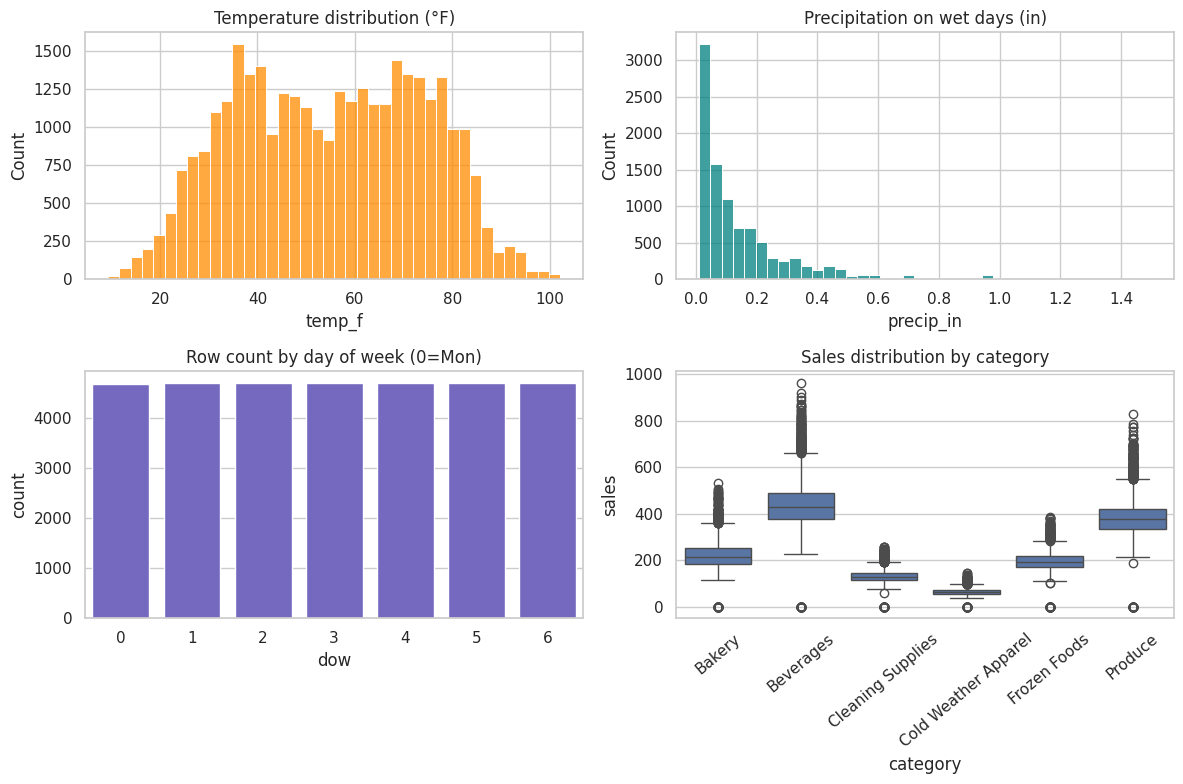

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["temp_f"], bins=40, ax=axes[0, 0], color="darkorange")
axes[0, 0].set_title("Temperature distribution (°F)")

sns.histplot(df.loc[df["precip_in"] > 0, "precip_in"], bins=40, ax=axes[0, 1], color="teal")
axes[0, 1].set_title("Precipitation on wet days (in)")

sns.countplot(x="dow", data=df, ax=axes[1, 0], color="slateblue")
axes[1, 0].set_title("Row count by day of week (0=Mon)")

sns.boxplot(x="category", y="sales", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Sales distribution by category")
axes[1, 1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()


### 2.3 Are features correlated with the response — and does it differ by category?

This is the core question of the project: *which categories are most sensitive to
weather and holidays?* We compute per-category correlations rather than one global
number, since a global correlation would wash out opposing effects (e.g. cold weather
boosts apparel but suppresses produce).


In [11]:
feature_cols = ["temp_f", "precip_in", "is_holiday", "is_weekend", "on_promo"]

corr_rows = []
for cat, g in df.groupby("category"):
    g2 = g.copy()
    for c in ["is_holiday", "is_weekend", "on_promo"]:
        g2[c] = g2[c].astype(float)
    corrs = g2[feature_cols + ["sales"]].corr()["sales"].drop("sales")
    corrs.name = cat
    corr_rows.append(corrs)

sensitivity = pd.concat(corr_rows, axis=1).T
sensitivity


,temp_f,precip_in,is_holiday,is_weekend,on_promo
Bakery,-0.065446,0.011810,-0.018299,0.611097,0.401966
Beverages,-0.081452,0.018046,-0.014654,0.460423,0.474755
Cleaning Supplies,-0.094623,-0.008874,-0.038066,0.312268,0.511575
Cold Weather Apparel,-0.090891,-0.007603,-0.012258,0.408193,0.488653
Frozen Foods,-0.103630,-0.020694,-0.013573,0.291131,0.482267
Produce,-0.101465,0.017074,-0.013607,0.312819,0.504157


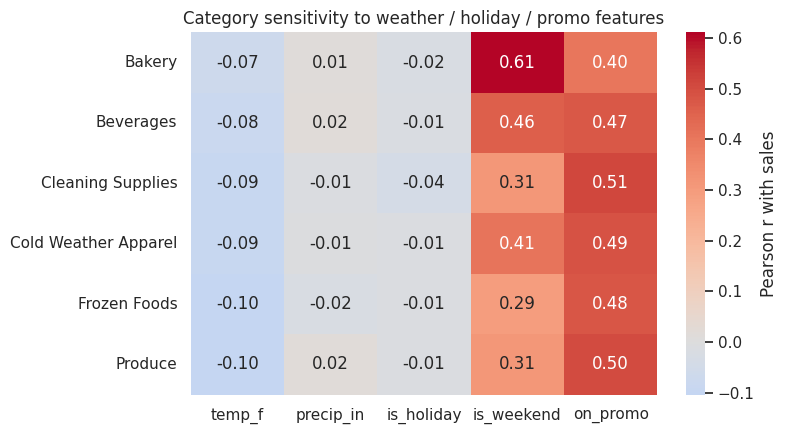

In [12]:
plt.figure(figsize=(8, 4.5))
sns.heatmap(sensitivity, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "Pearson r with sales"})
plt.title("Category sensitivity to weather / holiday / promo features")
plt.tight_layout()
plt.show()


**Reading this heatmap** is the direct answer to the project's second research
question — categories with the largest-magnitude coefficients (either sign) in the
`temp_f` / `precip_in` / `is_holiday` columns are the ones a weather- and
holiday-aware forecast will improve the most.


### 2.4 Are there collinear features?

Lag/rolling sales features are, by construction, collinear with each other and with
raw sales — important to know before feeding them all into a linear model.


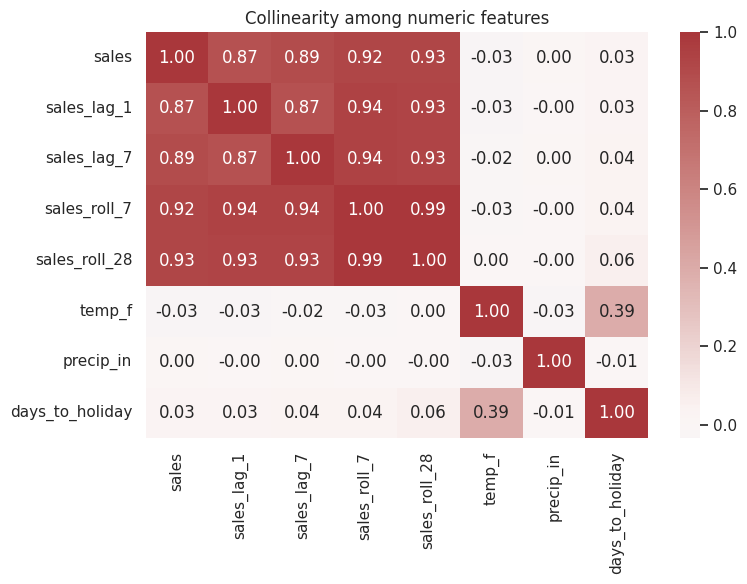

In [13]:
num_cols = ["sales", "sales_lag_1", "sales_lag_7", "sales_roll_7", "sales_roll_28",
            "temp_f", "precip_in", "days_to_holiday"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Collinearity among numeric features")
plt.tight_layout()
plt.show()


### 2.5 Are there outliers?

Boxplots by weather condition and by holiday status surface demand spikes/dips —
distinguishing genuine outliers (extreme weather, holiday surges) from stockout
artifacts (already flagged in wrangling).


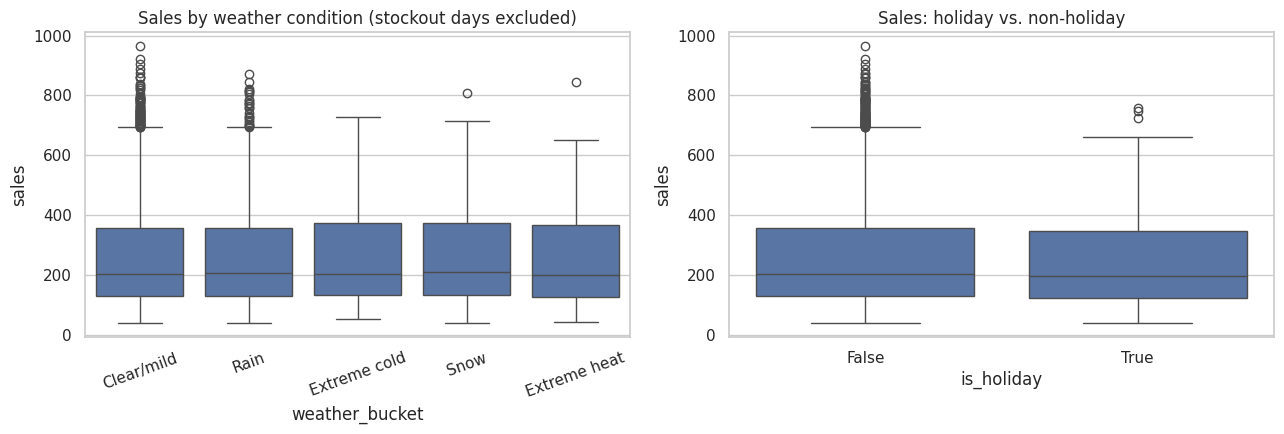

Flagged 651 statistical outliers (|z| > 3) out of 32868 rows


,date,store,category,sales,is_holiday,weather_bucket
37,2019-02-07,Store_1,Bakery,0.000000,False,Snow
60,2019-03-02,Store_1,Bakery,475.873912,False,Clear/mild
75,2019-03-17,Store_1,Bakery,420.257457,False,Rain
81,2019-03-23,Store_1,Bakery,415.194581,False,Clear/mild
203,2019-07-23,Store_1,Bakery,0.000000,False,Clear/mild
348,2019-12-15,Store_1,Bakery,419.355020,False,Clear/mild
362,2019-12-29,Store_1,Bakery,403.072962,False,Rain
398,2020-02-03,Store_1,Bakery,0.000000,False,Snow
403,2020-02-08,Store_1,Bakery,0.000000,False,Clear/mild
437,2020-03-13,Store_1,Bakery,0.000000,False,Clear/mild


In [14]:
df["weather_bucket"] = np.select(
    [df["extreme_cold"], df["extreme_heat"], df["snow_flag"], df["precip_in"] > 0],
    ["Extreme cold", "Extreme heat", "Snow", "Rain"],
    default="Clear/mild"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x="weather_bucket", y="sales", data=df[~df["stockout_flag"]], ax=axes[0])
axes[0].set_title("Sales by weather condition (stockout days excluded)")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(x="is_holiday", y="sales", data=df[~df["stockout_flag"]], ax=axes[1])
axes[1].set_title("Sales: holiday vs. non-holiday")

plt.tight_layout()
plt.show()

# simple z-score outlier flag per category series
df["sales_z"] = df.groupby("category")["sales"].transform(lambda s: (s - s.mean()) / s.std())
outliers = df[df["sales_z"].abs() > 3]
print(f"Flagged {len(outliers)} statistical outliers (|z| > 3) out of {len(df)} rows")
outliers[["date", "store", "category", "sales", "is_holiday", "weather_bucket"]].head(10)


### 2.6 Seasonal / linear trends

Line plots of total daily sales with holiday markers, plus a formal seasonal
decomposition (trend / weekly seasonality / residual) for one representative category.


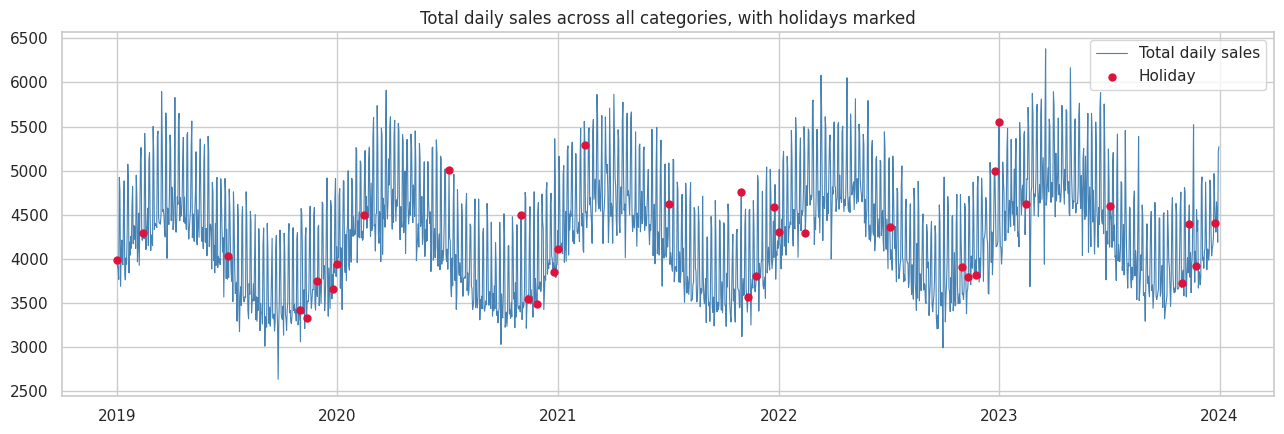

In [15]:
daily_total = df.groupby("date")["sales"].sum()

plt.figure(figsize=(13, 4.5))
plt.plot(daily_total.index, daily_total.values, lw=0.8, color="steelblue", label="Total daily sales")
hol_in_range = holidays_df[holidays_df["date"].between(daily_total.index.min(), daily_total.index.max())]
plt.scatter(hol_in_range["date"], daily_total.reindex(hol_in_range["date"]).values,
            color="crimson", zorder=5, label="Holiday", s=25)
plt.title("Total daily sales across all categories, with holidays marked")
plt.legend()
plt.tight_layout()
plt.show()


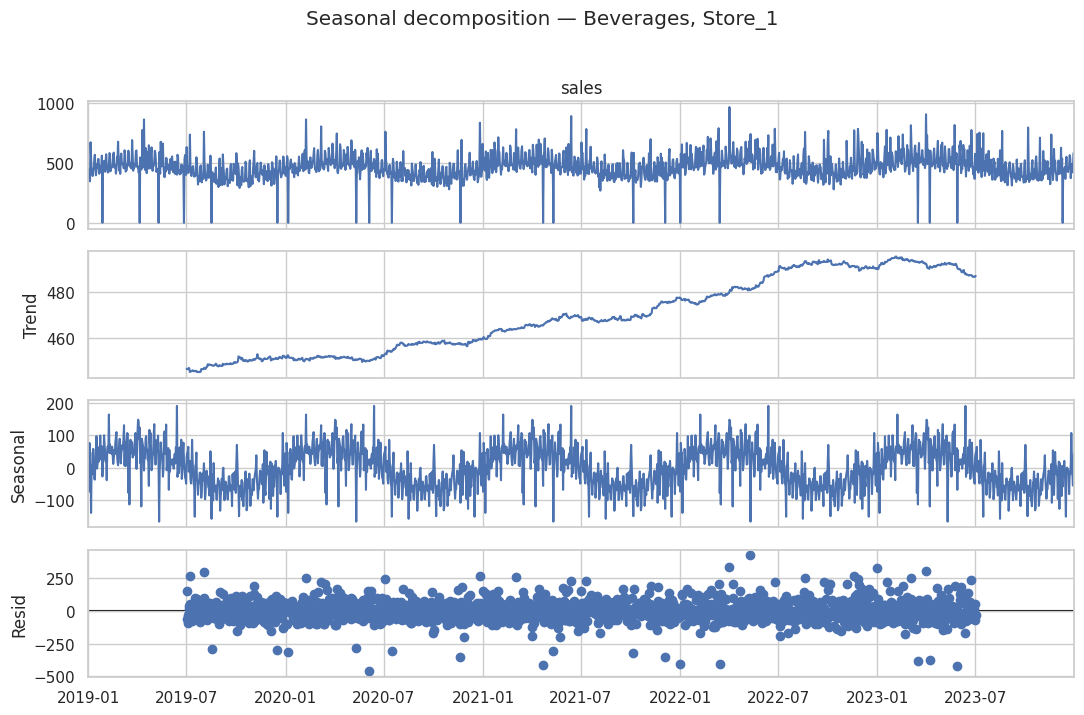

In [16]:
cat_for_decomp = "Beverages"
series = (df[(df["category"] == cat_for_decomp) & (df["store"] == "Store_1")]
          .set_index("date")["sales"].asfreq("D").interpolate())

decomp = seasonal_decompose(series, model="additive", period=365)
fig = decomp.plot()
fig.set_size_inches(11, 7)
fig.suptitle(f"Seasonal decomposition — {cat_for_decomp}, Store_1", y=1.02)
plt.tight_layout()
plt.show()


### 2.7 Category x weather scatter — spotting nonlinear thresholds

A single correlation coefficient can miss threshold effects (e.g. sales only spike
*below freezing*, not smoothly with temperature). Faceted scatter plots make these visible.


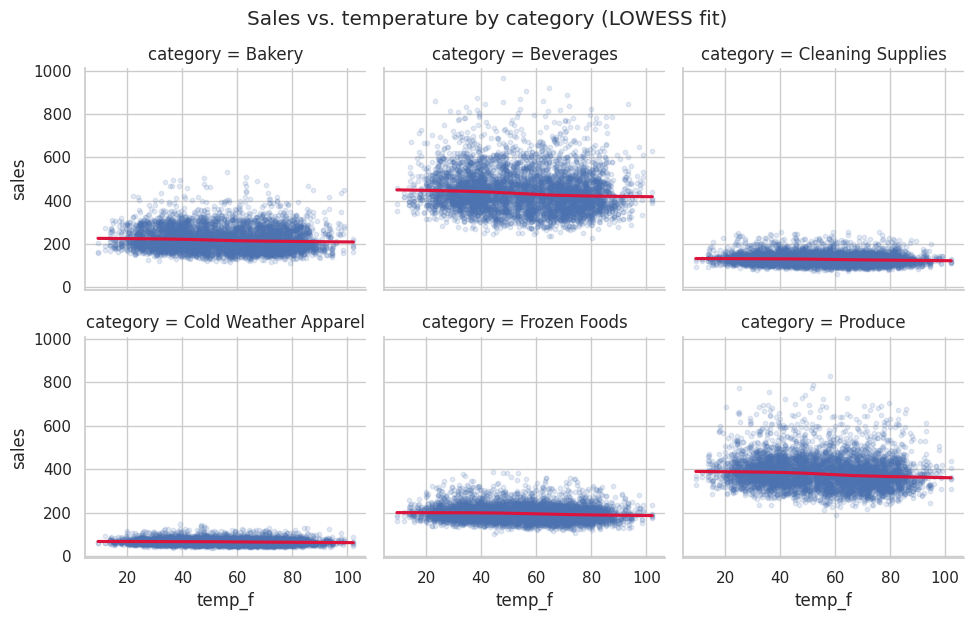

In [17]:
g = sns.lmplot(
    data=df[~df["stockout_flag"]], x="temp_f", y="sales", col="category", col_wrap=3,
    scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "crimson"}, height=3, aspect=1.1,
    lowess=True
)
g.fig.suptitle("Sales vs. temperature by category (LOWESS fit)", y=1.03)
plt.show()


---
## 3. EDA Summary — feeding into modeling

- **Response shape:** sales are right-skewed with category-specific zero-inflation
  driven mostly by stockouts (flagged and excludable) rather than genuine zero-demand days.
- **Weather sensitivity:** the correlation heatmap (2.3) and faceted scatter plots (2.7)
  identify which categories move with temperature/precipitation and whether the
  relationship is linear or threshold-based — this directly answers "which categories
  are most sensitive to external factors."
- **Holiday effect:** boxplots (2.5) and the marked line plot (2.6) show holiday-day
  sales lift relative to baseline, and `days_to_holiday` captures the pre-holiday ramp.
- **Collinearity:** lag/rolling sales features are highly collinear with each other —
  use regularization (Ridge/Lasso) or tree-based models that handle collinearity natively,
  or drop redundant lags.
- **Next steps:** feed `train`/`test` (Section 1.5) into a baseline (seasonal naive /
  SARIMA) and a weather-and-holiday-aware model (e.g. gradient-boosted trees or
  Prophet with regressors), and compare forecast error with vs. without the external
  features — directly testing the project's core hypothesis.
